In [1]:
import numpy as np


import matplotlib.pyplot as plt
import matplotlib.animation as animation
import qutip as qt

# Analytic stark shift

In [4]:

plt.style.use('dark_background')

In [5]:
[lvl_lables[0] + r'$\rightarrow$'+ lvl_lables[1]]

NameError: name 'lvl_lables' is not defined

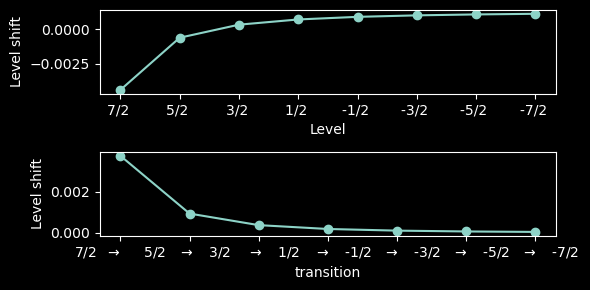

In [ ]:
d = 8
splitting = 1
levels = np.arange(d) 
freq_ids = np.arange(d-1)
lvl_lables = [str(i)+ r'/2 ' for i in np.arange((d-1), -(d-1) - 1, -2)]
freq_labels = [r'       $\rightarrow$   ' + lvl_lables[i+1] for i in range(1, d-1)]
freq_labels = [lvl_lables[0] + r' $\rightarrow$     '+ lvl_lables[1], *freq_labels]
freqs = splitting * np.arange(-(d/2-1), d/2)
couplings = np.abs(np.diag(qt.jmat((d-1)/2, 'x').full(), 1))

lvl_shift = np.zeros(d)
f = -5; amp = 0.1
for lvl in levels:
    if lvl > 0:
        det = freqs[lvl-1] - f
        if det != 0:
            lvl_shift[lvl] += (couplings[lvl-1]*amp)**2/(2*det)
    if lvl < d-1:
        det = freqs[lvl] - f
        if det != 0:
            lvl_shift[lvl] -= (couplings[lvl]*amp)**2/(2*det)

freq_shift = lvl_shift[freq_ids+1] - lvl_shift[freq_ids]

fig, axs = plt.subplots(2, figsize=(6,3))
ax = axs[0]
ax.plot(levels, lvl_shift, 'o-')
ax.set_xticks(levels, lvl_lables)
ax.set_xlabel('Level')
ax.set_ylabel('Level shift')
ax = axs[1]
ax.plot(freq_ids, freq_shift, 'o-')
ax.set_xticks(freq_ids, freq_labels)
ax.set_xlabel('transition')
ax.set_ylabel('Level shift')
fig.tight_layout()

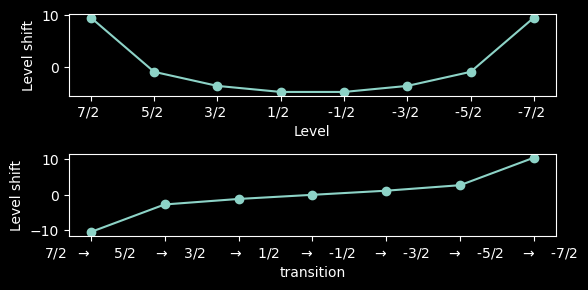

In [6]:
d = 8
splitting = 25e3
levels = np.arange(d) 
freq_ids = np.arange(d-1)
lvl_lables = [str(i)+ r'/2 ' for i in np.arange((d-1), -(d-1) - 1, -2)]
freq_labels = [r'       $\rightarrow$   ' + lvl_lables[i+1] for i in range(1, d-1)]
freq_labels = [lvl_lables[0] + r' $\rightarrow$     '+ lvl_lables[1], *freq_labels]
freqs = splitting * np.arange(-(d/2-1), d/2)
couplings = np.abs(np.diag(qt.jmat((d-1)/2, 'x').full(), 1))

lvl_shift = np.zeros(d)
amp = 1/3e-3
for f in freqs:
    for lvl in levels:
        if lvl > 0:
            det = freqs[lvl-1] - f
            if det != 0:
                lvl_shift[lvl] += (couplings[lvl-1]*amp)**2/(2*det)
        if lvl < d-1:
            det = freqs[lvl] - f
            if det != 0:
                lvl_shift[lvl] -= (couplings[lvl]*amp)**2/(2*det)

freq_shift = lvl_shift[freq_ids+1] - lvl_shift[freq_ids]

fig, axs = plt.subplots(2, figsize=(6,3))
ax = axs[0]
ax.plot(levels, lvl_shift, 'o-')
ax.set_xticks(levels, lvl_lables)
ax.set_xlabel('Level')
ax.set_ylabel('Level shift')
ax = axs[1]
ax.plot(freq_ids, freq_shift, 'o-')
ax.set_xticks(freq_ids, freq_labels)
ax.set_xlabel('transition')
ax.set_ylabel('Level shift')
fig.tight_layout()

array([4.5, 2. , 0.5, 0. , 0.5, 2. , 4.5])

In [7]:
def calc_nmr_stark_shift(drive_freqs, splitting, amps, d = 8, sec_ord_splitting=0, plot=True):
    if isinstance(drive_freqs, (int, float)):
        drive_freqs = np.array([drive_freqs])
        
    if isinstance(amps, (list, np.ndarray)):
        amps = np.array(amps)
    else:
        amps = np.full_like(drive_freqs, amps)
    
    levels = np.arange(d) 
    freq_ids = np.arange(d-1)
    lvl_lables = [str(i)+ r'/2 ' for i in np.arange((d-1), -(d-1) - 1, -2)]
    freq_labels = [r'       $\rightarrow$   ' + lvl_lables[i+1] for i in range(1, d-1)]
    freq_labels = [lvl_lables[0] + r' $\rightarrow$     '+ lvl_lables[1], *freq_labels]
    freqs = splitting * np.arange(-(d/2-1), d/2) + np.arange(-(d/2-1), d/2)**2/2*sec_ord_splitting
    couplings = np.abs(np.diag(qt.jmat((d-1)/2, 'x').full(), 1))

    lvl_shift = np.zeros(d)
    for i, f in enumerate(drive_freqs):
        for lvl in levels:
            if lvl > 0:
                det = freqs[lvl-1] - f
                if np.abs(det) > 1:
                    lvl_shift[lvl] += (couplings[lvl-1]*amps[i])**2/(2*det)
            if lvl < d-1:
                det = freqs[lvl] - f
                if np.abs(det) > 1:
                    lvl_shift[lvl] -= (couplings[lvl]*amps[i])**2/(2*det)

    freq_shift = lvl_shift[freq_ids+1] - lvl_shift[freq_ids]

    if plot:
        fig, axs = plt.subplots(2, figsize=(6,3))
        ax = axs[0]
        ax.plot(levels, lvl_shift, 'o-')
        ax.set_xticks(levels, lvl_lables)
        ax.set_xlabel('Level')
        ax.set_ylabel('Level shift')
        ax.set_xlim(-0.25, d-1+0.25)
        ax.grid()
        ax = axs[1]
        ax.plot(0.5+np.arange(d-1), freq_shift, 'o-')
        ax.set_xlim(-0.25, d-1+0.25)
        ax.set_xticks(0.5+np.arange(d-1), freq_labels)
        ax.set_xlabel('transition')
        ax.set_ylabel('resonance shift')
        ax.grid()
        fig.tight_layout()
    return freq_shift, lvl_shift

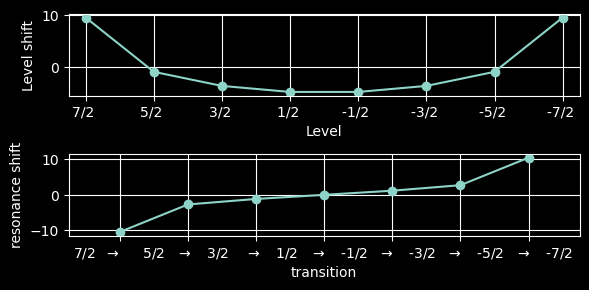

In [8]:
fq = 25e3; fq2 = 0
all_freqs = np.arange(-3, 4)*fq + np.arange(-3, 4)**2/2*fq2
freq_shift, lvl_shifts = calc_nmr_stark_shift(all_freqs, fq, 1/3e-3, sec_ord_splitting=fq2)

ValueError: Input could not be cast to an at-least-1D NumPy array

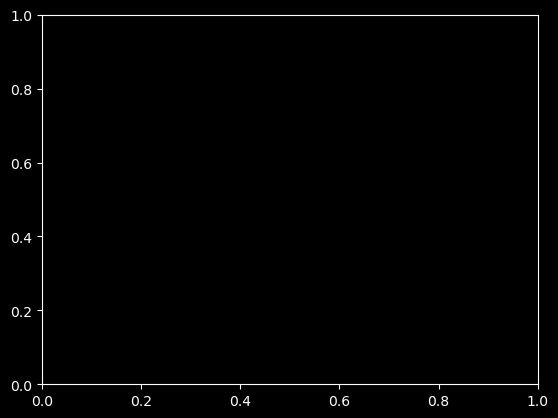

In [9]:
self_stark_shift = []
all_freqs = np.arange(-3, 4)*fq + np.arange(-3, 4)**2/2*fq2
for i, f in enumerate(all_freqs):
    freq_shift = calc_nmr_stark_shift(f, fq, 1/6e-3, sec_ord_splitting=fq2, plot=False)
    plt.plot(freq_shift)
    self_stark_shift.append(freq_shift[i])
self_stark_shift = np.array(self_stark_shift)
plt.figure()
plt.plot(self_stark_shift)

In [ ]:
rabi_freqs = 7/6e-3*np.abs(np.diag(qt.jmat((d-1)/2, 'x').full(), 1))

rabi_freqs_shift = np.sqrt(rabi_freqs**2 + self_stark_shift**2)

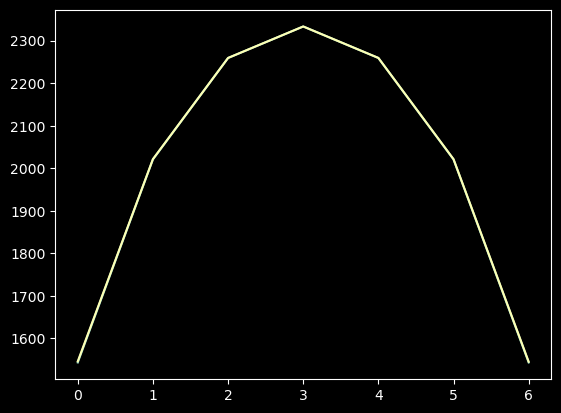

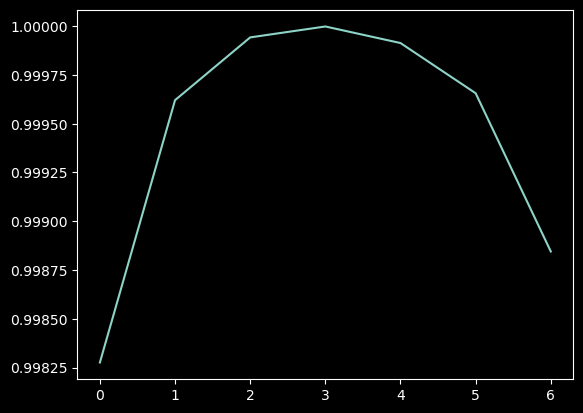

In [ ]:
plt.plot(rabi_freqs)
plt.plot(rabi_freqs_shift)

plt.figure()
plt.plot(rabi_freqs/rabi_freqs_shift)

# Stark shift on GR

In [ ]:
Ix = qt.jmat(7/2, 'x')
Iz = qt.jmat(7/2, 'z')
Iz_diag = np.diag(np.real(Iz.full()))

In [ ]:
def get_pop(state):
    pops = np.abs(state.full())**2
    return pops.flatten()

In [ ]:
fq

25000.0

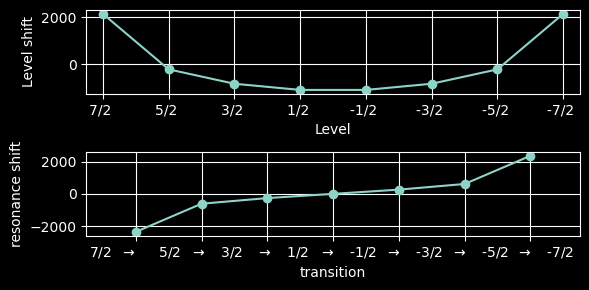

In [ ]:
angles = np.linspace(0, 2*np.pi, 100)
init_state = qt.basis(8, 0)
nmr_amp = 1/2e-4
fq = 25e3; fq2 = 0
all_freqs = np.arange(-3, 4)*fq + np.arange(-3, 4)**2/2*fq2
freq_shift, lvl_shift = calc_nmr_stark_shift(all_freqs, fq, nmr_amp, sec_ord_splitting=fq2)
Hdet = np.zeros((8,8), dtype=np.complex128)
for i in range(8):
    Hdet[i, i] = lvl_shift[i]
H = qt.Qobj(Hdet) + nmr_amp*Ix

pops = np.zeros((len(angles), 8))
for ia, angle in enumerate(angles):
    state = (H*1j*angle/nmr_amp).expm() * init_state
    pops[ia] = get_pop(state)
Iz_exp = np.sum(pops *Iz_diag,1)

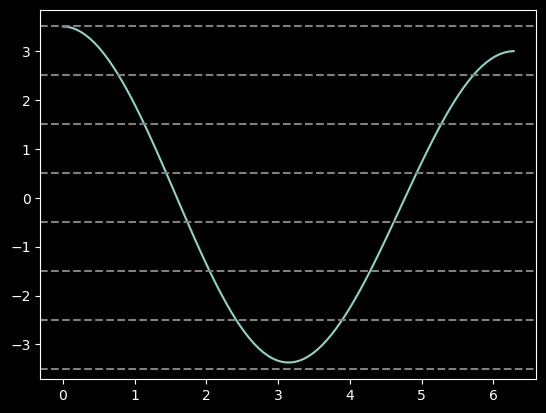

In [ ]:
plt.plot(angles, Iz_exp)
for i in range(8):
    plt.axhline(Iz_diag[i], color='gray', linestyle='--')

In [ ]:
0.5/0.003027364

165.16018556077168

np.float64(-0.005735148216055189)

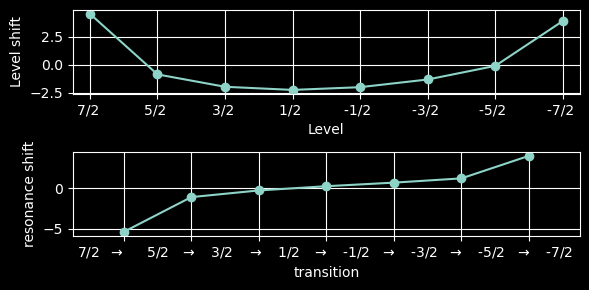

In [ ]:
angles = np.linspace(0, 2*np.pi, 100)
init_state = (1j*np.pi/2*Ix).expm()*qt.basis(8, 0)
nmr_amp = 165.16
fq = 14e3; fq2 = 600
all_freqs = np.arange(-3, 4)*fq + np.arange(-3, 4)**2/2*fq2
freq_shift, lvl_shift = calc_nmr_stark_shift(all_freqs, fq, nmr_amp, sec_ord_splitting=fq2)
Hdet = np.zeros((8,8), dtype=np.complex128)
for i in range(8):
    Hdet[i, i] = lvl_shift[i]
H = qt.Qobj(Hdet) + nmr_amp*Ix
state_up = (-1j*H*(np.pi/2)/nmr_amp).expm() * init_state
H = qt.Qobj(Hdet) - nmr_amp*Ix
state_down = (-1j*H*(np.pi/2)/nmr_amp).expm() * state_up
parity_op = np.eye(8, dtype=np.complex128)
for i in range(4):
    parity_op[2*i, 2*i] = -1
parity = qt.expect(qt.Qobj(parity_op), state_down)
parity_angle_offset = np.arcsin(parity)/np.pi*180
parity_angle_offset

# Second order

In [ ]:
couplings

array([2.29128785, 3.35410197, 3.87298335, 3.87298335, 3.35410197,
       2.29128785])

In [ ]:
0.9/6

0.15

In [ ]:
903/6

150.5

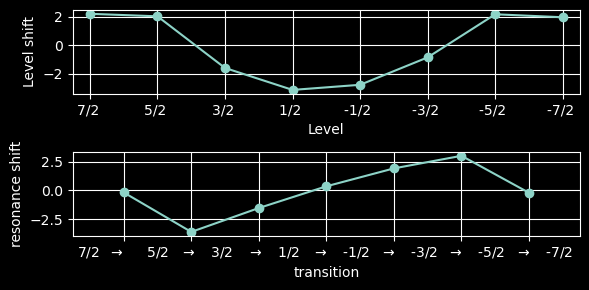

In [12]:
d = 8
splitting = 14.5e3; fq2 = 600
levels = np.arange(d) 
freq_ids = np.arange(d-2)
lvl_lables = [str(i)+ r'/2 ' for i in np.arange((d-1), -(d-1) - 1, -2)]

freq_labels = [r'       $\rightarrow$   ' + lvl_lables[i+1] for i in range(1, d-1)]
freq_labels = [lvl_lables[0] + r' $\rightarrow$     '+ lvl_lables[1], *freq_labels]


freqs1 = splitting * np.arange(-(d/2-1), d/2)  + fq2*np.arange(-(d/2-1), d/2)**2/2# first order 
freqs = freqs1[1:] + freqs1[:-1]
couplings = np.abs(np.diag((qt.jmat((d-1)/2, 'x')**2).full()/2, 2))

lvl_shift = np.zeros(d)
amp = 200 #1/3e-3
for f in freqs:
    for lvl in levels:
        if lvl > 1:
            det = freqs[lvl-2] - f
            if det != 0:
                lvl_shift[lvl] += (couplings[lvl-2]*amp)**2/(2*det)
        if lvl < d-2:
            det = freqs[lvl] - f
            if det != 0:
                # if lvl < 2:
                #     print(lvl, couplings[lvl], det, (couplings[lvl]*amp)**2/(2*det))
                lvl_shift[lvl] -= (couplings[lvl]*amp)**2/(2*det)

freq_shift = lvl_shift[1:] - lvl_shift[:-1]

fig, axs = plt.subplots(2, figsize=(6,3))
ax = axs[0]
ax.plot(levels, lvl_shift, 'o-')
ax.set_xticks(levels, lvl_lables)
ax.set_xlabel('Level')
ax.set_ylabel('Level shift')
ax.set_xlim(-0.25, d-1+0.25)
ax.grid()
ax = axs[1]
ax.plot(0.5+np.arange(d-1), freq_shift, 'o-')
ax.set_xlim(-0.25, d-1+0.25)
ax.set_xticks(0.5+np.arange(d-1), freq_labels)
ax.set_xlabel('transition')
ax.set_ylabel('resonance shift')
ax.grid()
fig.tight_layout()


In [14]:
lvl_shift

array([ 2.1962355 ,  2.02067273, -1.59184034, -3.12560656, -2.76745576,
       -0.84966546,  2.1630606 ,  1.95459929])

In [ ]:
freqs2

array([-100000.,  -60000.,  -20000.,   20000.,   60000.,  100000.])

# full electric stark shift

# the first order NER is quite far detuned so don't expect this to be much

In [ ]:

def calc_ner_stark_shift(drive_freqs, splitting, amps, alphas=[1, 1], d=8, sec_ord_splitting=0, zeeman=7.7e6, plot=True):
    if isinstance(drive_freqs, (int, float)):
        drive_freqs = np.array([drive_freqs])
        
    if isinstance(amps, (list, np.ndarray)):
        amps = np.array(amps)
    else:
        amps = np.full_like(drive_freqs, amps)
    
    levels = np.arange(d) 
    lvl_lables = [str(i)+ r'/2 ' for i in np.arange((d-1), -(d-1) - 1, -2)]
    freq_labels = [r'       $\rightarrow$   ' + lvl_lables[i+1] for i in range(1, d-1)]
    freq_labels = [lvl_lables[0] + r' $\rightarrow$     '+ lvl_lables[1], *freq_labels]
    freqs1 = zeeman + splitting * np.arange(-(d/2-1), d/2) + np.arange(-(d/2-1), d/2)**2/2*sec_ord_splitting
    freqs2 = freqs1[1:] + freqs1[:-1]

    Ix = qt.jmat((d-1)/2, 'x'); Iz = qt.jmat((d-1)/2, 'z')
    couplings1 = np.real(np.diag(((Ix*Iz + Iz*Ix)/2).full(), 1))
    couplings2 = np.abs(np.diag((qt.jmat((d-1)/2, 'x')**2/2).full(), 2))

    lvl_shift = np.zeros(d)


    for i, f in enumerate(drive_freqs):
        for lvl in levels:
            if lvl > 0:
                det = freqs1[lvl-1] - f
                if det != 0:
                    lvl_shift[lvl] += (couplings1[lvl-2]*alphas[0]*amps[i])**2/(2*det)

                if lvl > 1:
                    det = freqs2[lvl-2] - f
                    if det != 0:
                        lvl_shift[lvl] += (couplings2[lvl-2]*alphas[1]*amps[i])**2/(2*det)
            if lvl < d-1:
                det = freqs1[lvl] - f
                if det != 0:
                    lvl_shift[lvl] -= (couplings1[lvl]*alphas[0]*amps[i])**2/(2*det)
            if lvl < d-2:
                det = freqs2[lvl] - f
                if det != 0:
                    lvl_shift[lvl] -= (couplings2[lvl]*alphas[1]*amps[i])**2/(2*det)

    freq_shift = lvl_shift[1:] - lvl_shift[:-1]
    if plot:
        fig, axs = plt.subplots(2, figsize=(6,3))
        ax = axs[0]
        ax.plot(levels, lvl_shift, 'o-')
        ax.set_xticks(levels, lvl_lables)
        ax.set_xlabel('Level')
        ax.set_ylabel('Level shift')
        ax.set_xlim(-0.25, d-1+0.25)
        ax.grid()
        ax = axs[1]
        ax.plot(0.5+np.arange(d-1), freq_shift, 'o-')
        ax.set_xlim(-0.25, d-1+0.25)
        ax.set_xticks(0.5+np.arange(d-1), freq_labels)
        ax.set_xlabel('transition')
        ax.set_ylabel('resonance shift')
        ax.grid()
        fig.tight_layout()
        
    return freq_shift

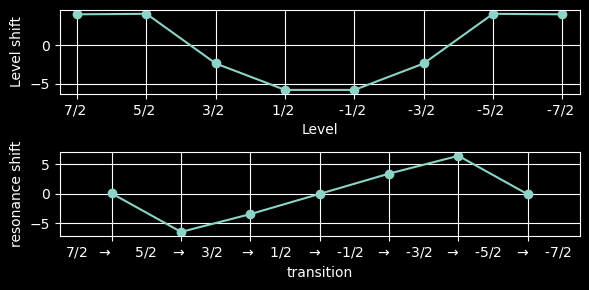

In [ ]:
zeeman = 7.7e6
fq = 25e3; fq2 =0
all_ner1_freqs = zeeman +  np.arange(-3, 4)*fq + np.arange(-3, 4)**2/2*fq2
all_ner2_freqs = all_ner1_freqs[1:] + all_ner1_freqs[:-1] 
freq_shift = calc_ner_stark_shift(all_ner2_freqs, fq, 1/3e-3*1.1, alphas=[0, 1], sec_ord_splitting=fq2, zeeman=zeeman)

In [ ]:
freq_shift

array([ 0.06722222, -6.44493056, -3.42833333,  0.        ,  3.42833333,
        6.44493056, -0.06722222])